# Fraud Detection — Modeling

## Objective
This notebook develops machine learning models to detect fraudulent transactions using the merged transaction and identity datasets.

The modeling workflow is guided by findings from exploratory data analysis:

- the target is imbalanced, with fraud representing approximately **3.5%** of transactions
- the dataset contains substantial missingness, and missingness itself appears informative for some variables
- categorical variables have mixed cardinality, with mostly low-cardinality features and a few high-cardinality ones
- `TransactionAmt` is strongly right-skewed, motivating a log-transformed feature
- individual linear correlations with fraud are weak, suggesting that nonlinear models may be more effective

## Modeling Goals
The business goal is to identify as many fraudulent transactions as possible while keeping false positives at a manageable level.

Accordingly, model evaluation will prioritize:

- **PR-AUC**
- **Recall**
- **Precision**
- **F1-score**
- **ROC-AUC** as a secondary ranking metric

Accuracy is not treated as a primary metric because of class imbalance.

## Modeling Strategy
This notebook will:

1. load and merge the raw datasets  
2. recreate EDA-informed feature transformations  
3. remove identifier columns and extremely sparse variables  
4. add missingness indicators for informative fields  
5. apply cardinality-aware encoding to categorical features  
6. train baseline and nonlinear models  
7. evaluate models using fraud-appropriate metrics  
8. compare random-split and time-based validation  
9. add rolling time validation for stronger temporal robustness assessment  
10. tune the classification threshold  
11. inspect feature importance and prediction errors  
12. save the best modeling pipeline

In [1]:
# =========================================
# 1. Imports and notebook settings
# =========================================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

## 1. Load and Merge Data

The training data is split into:
- a transaction-level table
- an identity-level table

These are merged on `TransactionID` using a left join so that all transactions are retained.

In [2]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        # =========================================
# 2. Load and merge data
# =========================================
train_txn = pd.read_csv("../data/raw/train_transaction.csv")
train_id = pd.read_csv("../data/raw/train_identity.csv")

print("Transaction dataset shape:", train_txn.shape)
print("Identity dataset shape:", train_id.shape)

df = train_txn.merge(train_id, on="TransactionID", how="left")

print("Merged dataset shape:", df.shape)

memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Approximate memory usage: {memory_mb:.2f} MB")

Transaction dataset shape: (590540, 394)
Identity dataset shape: (144233, 41)
Merged dataset shape: (590540, 434)
Approximate memory usage: 2567.09 MB


### Interpretation

The merged dataset retains the full transaction population and adds identity information where available. As observed in the EDA stage, this merge introduces substantial missingness in identity-related features because identity records are only available for a subset of transactions.

Given the size and width of the dataset, memory-aware preprocessing and targeted feature selection will be important in the modeling pipeline.

## 2. Recreate EDA-Informed Feature Engineering

Exploratory analysis showed that:

- `TransactionAmt` is strongly right-skewed
- missingness itself is informative for selected variables

To make the modeling workflow reproducible, these transformations are recreated here rather than relying on the EDA notebook.

In [3]:
# =========================================
# 3. EDA-informed feature engineering
# =========================================

# Log-transform transaction amount
df["log_TransactionAmt"] = np.log1p(df["TransactionAmt"])

# Missingness indicators for columns that showed informative missingness in EDA
missing_signal_cols = ["DeviceType", "dist1", "dist2", "id_30", "id_31"]

for col in missing_signal_cols:
    if col in df.columns:
        df[f"{col}_missing"] = df[col].isnull().astype(int)

print("Added engineered features:")
print([col for col in df.columns if col.endswith("_missing")] + ["log_TransactionAmt"])

Added engineered features:
['DeviceType_missing', 'dist1_missing', 'dist2_missing', 'id_30_missing', 'id_31_missing', 'log_TransactionAmt']


### Interpretation

These engineered variables are based directly on insights discovered during EDA:

- `log_TransactionAmt` reduces skewness and stabilizes extreme transaction values
- missingness indicators preserve predictive signal from fields whose presence or absence is associated with fraud risk

This keeps the modeling workflow reproducible and independent of the exploratory notebook.

## 3. Remove Identifier Columns and Extremely Sparse Features

`TransactionID` is a unique identifier and is not suitable as a predictive feature.

We also remove columns with extremely high missingness. Based on the EDA findings, the goal is not to drop every column above 50% missing, but to remove the most severely sparse features while preserving potentially informative variables and their missingness indicators.

In [4]:
# =========================================
# 4. Remove identifiers and extreme sparsity
# =========================================
target = "isFraud"

# Drop identifier
drop_cols = ["TransactionID"]

# Extreme sparsity rule
missing_ratio = df.isnull().mean()
extremely_sparse_cols = missing_ratio[missing_ratio > 0.95].index.tolist()

# Keep target safe
extremely_sparse_cols = [col for col in extremely_sparse_cols if col != target]

# Combine drops
drop_cols = list(set(drop_cols + extremely_sparse_cols))

df = df.drop(columns=drop_cols)

print(f"Dropped columns: {len(drop_cols)}")
print("Remaining dataset shape:", df.shape)

Dropped columns: 10
Remaining dataset shape: (590540, 430)


### Interpretation

The modeling dataset excludes the transaction identifier and removes only the most extremely sparse columns (10). This is a more conservative and realistic strategy than dropping all columns with moderate or high missingness.

The remaining missing values will be handled through imputation, while selected missingness indicators preserve information from null patterns that may be predictive.

## 4. Define Features and Target

The fraud label `isFraud` is separated from the predictor set.

In [5]:
# =========================================
# 5. Define X and y
# =========================================
y = df[target]
X = df.drop(columns=[target])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print(f"Fraud rate: {y.mean() * 100:.2f}%")

Feature matrix shape: (590540, 429)
Target shape: (590540,)
Fraud rate: 3.50%


## 5. Create a Random Split Baseline

A stratified random split is used as the first benchmark so that the fraud rate remains consistent across training and validation sets.

This provides a standard reference point before moving to more realistic temporal validation.

In [6]:
# =========================================
# 6. Random train/validation split
# =========================================
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print(f"Train fraud rate: {y_train.mean() * 100:.2f}%")
print(f"Valid fraud rate: {y_valid.mean() * 100:.2f}%")

X_train: (472432, 429)
X_valid: (118108, 429)
Train fraud rate: 3.50%
Valid fraud rate: 3.50%


## 6. Identify Feature Types and Categorical Cardinality

The EDA stage showed that categorical variables are mostly low-cardinality, with a few high-cardinality columns.

We use that insight here to determine the encoding strategy:

- **Low-cardinality categorical variables** → one-hot encoding
- **High-cardinality categorical variables** → frequency encoding

In [7]:
# =========================================
# 7. Feature type identification
# =========================================
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

cardinality = X_train[categorical_cols].nunique(dropna=True).sort_values(ascending=False)
cardinality_df = cardinality.reset_index()
cardinality_df.columns = ["feature", "unique_values"]

display(cardinality_df)

Numeric columns: 400
Categorical columns: 29


,feature,unique_values
0,DeviceInfo,1686
1,id_33,236
2,id_31,124
3,id_30,75
4,R_emaildomain,60
5,P_emaildomain,59
6,ProductCD,5
7,card6,4
8,id_34,4
9,card4,4


In [8]:
low_card_cols = [col for col in categorical_cols if X_train[col].nunique(dropna=True) <= 10]
high_card_cols = [col for col in categorical_cols if X_train[col].nunique(dropna=True) > 10]

print("Low-cardinality categorical columns:", len(low_card_cols))
print("High-cardinality categorical columns:", len(high_card_cols))

print("\nLow-cardinality features:")
print(low_card_cols)

print("\nHigh-cardinality features:")
print(high_card_cols)

Low-cardinality categorical columns: 23
High-cardinality categorical columns: 6

Low-cardinality features:
['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']

High-cardinality features:
['P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33', 'DeviceInfo']


### Interpretation

The encoding strategy is chosen based on cardinality rather than applying the same treatment to all categorical variables.

This avoids unnecessary dimensionality expansion while preserving useful category-level information. It also reflects a more production-minded preprocessing design, especially for a wide fraud dataset.

## 7. Frequency Encode High-Cardinality Categorical Variables

High-cardinality categorical features are encoded using category frequency from the training set.

This avoids creating very large sparse matrices while still preserving category prevalence information.

In [9]:
# =========================================
# 8. Frequency encoding for high-cardinality columns
# =========================================
def frequency_encode(train_df, valid_df, columns):
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    for col in columns:
        freq_map = train_df[col].value_counts(dropna=False, normalize=True)
        train_df[col] = train_df[col].map(freq_map)
        valid_df[col] = valid_df[col].map(freq_map).fillna(0)

    return train_df, valid_df

X_train_fe, X_valid_fe = frequency_encode(X_train, X_valid, high_card_cols)

print("Frequency encoding applied to high-cardinality columns.")

Frequency encoding applied to high-cardinality columns.


## 8. Build the Preprocessing Pipeline

The remaining preprocessing steps are:

- median imputation for numeric variables
- most-frequent imputation for low-cardinality categorical variables
- one-hot encoding for low-cardinality categorical variables

This preprocessing setup is used consistently across models.

In [10]:
# =========================================
# 9. Preprocessing pipeline
# =========================================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, X_train_fe.select_dtypes(include=[np.number]).columns.tolist()),
        ("cat", categorical_transformer, low_card_cols)
    ]
)

## 9. Handle Class Imbalance Professionally

The training data contains far more legitimate transactions than fraudulent ones.

For this project, the first imbalance-handling approach will be:

- **class weighting** for Logistic Regression and Random Forest
- **`scale_pos_weight`** for XGBoost

This is preferred as an initial professional baseline over synthetic oversampling because it is simpler, more production-friendly, and preserves the original data distribution.

In [11]:
# =========================================
# 10. Class imbalance ratio
# =========================================
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Negative class count: {neg}")
print(f"Positive class count: {pos}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Negative class count: 455902
Positive class count: 16530
scale_pos_weight: 27.58


### Class Imbalance Interpretation

The training data is strongly imbalanced, with **455,902 legitimate transactions** and **16,530 fraudulent transactions**. This corresponds to a negative-to-positive ratio of approximately **27.6:1**.

This confirms that fraud detection should be treated as an **imbalance-aware classification problem**. In practical terms, a model trained without compensating for this imbalance would tend to favor the majority class and under-detect fraud.

To address this, the modeling pipeline uses:

- **class weighting** for Logistic Regression and Random Forest
- **`scale_pos_weight = 27.58`** for XGBoost

This is an approach that preserves the original data distribution while making the model more sensitive to the minority fraud class.

## 10. Define Models

Three models will be trained:

1. **Logistic Regression**  
   A simple and interpretable baseline.

2. **Random Forest**  
   A nonlinear ensemble baseline.

3. **XGBoost**  
   The main candidate model, chosen because EDA suggests that fraud patterns are subtle, interaction-driven, and weakly linear at the univariate level.

In [12]:
# =========================================
# 11. Define models
# =========================================
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

## 11. Create Modeling Pipelines

Each model is wrapped in a pipeline so that preprocessing and model training remain linked and reproducible.

In [13]:
# =========================================
# 12. Create pipelines
# =========================================
log_reg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", log_reg)
])

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf)
])

xgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

## 12. Define the Evaluation Function

Because this is an imbalanced fraud problem, the evaluation function focuses on:

- ROC-AUC
- PR-AUC
- Precision
- Recall
- F1-score

These metrics are more appropriate than raw accuracy for this task.

In [14]:
# =========================================
# 13. Evaluation function
# =========================================
def evaluate_model(name, model, X_valid, y_valid, threshold=0.5):
    probs = model.predict_proba(X_valid)[:, 1]
    preds = (probs >= threshold).astype(int)

    results = {
        "model": name,
        "roc_auc": roc_auc_score(y_valid, probs),
        "pr_auc": average_precision_score(y_valid, probs),
        "precision": precision_score(y_valid, preds, zero_division=0),
        "recall": recall_score(y_valid, preds, zero_division=0),
        "f1": f1_score(y_valid, preds, zero_division=0)
    }

    print(f"\n{name}")
    for metric, value in results.items():
        if metric != "model":
            print(f"{metric}: {value:.4f}")

    return probs, preds, results

## 13. Train Models on the Random Split

In [15]:
# =========================================
# 14. Train models
# =========================================
log_reg_pipe.fit(X_train_fe, y_train)
rf_pipe.fit(X_train_fe, y_train)
xgb_pipe.fit(X_train_fe, y_train)

print("All models trained successfully.")

All models trained successfully.


## 14. Evaluate Model Performance on the Random Split at the Default Threshold

All models are first evaluated at the standard threshold of **0.50** as an initial benchmark.

In [16]:
# =========================================
# 15. Evaluate models at threshold 0.50
# =========================================
log_probs, log_preds, log_results = evaluate_model("Logistic Regression", log_reg_pipe, X_valid_fe, y_valid, threshold=0.50)
rf_probs, rf_preds, rf_results = evaluate_model("Random Forest", rf_pipe, X_valid_fe, y_valid, threshold=0.50)
xgb_probs, xgb_preds, xgb_results = evaluate_model("XGBoost", xgb_pipe, X_valid_fe, y_valid, threshold=0.50)


Logistic Regression
roc_auc: 0.7460
pr_auc: 0.1312
precision: 0.0702
recall: 0.6642
f1: 0.1270

Random Forest
roc_auc: 0.9003
pr_auc: 0.5671
precision: 0.2121
recall: 0.7387
f1: 0.3296

XGBoost
roc_auc: 0.9388
pr_auc: 0.6612
precision: 0.2486
recall: 0.8193
f1: 0.3814


## Random-Split Model Comparison

The initial benchmark compared three models on a stratified random validation split:

- **Logistic Regression**
- **Random Forest**
- **XGBoost**

### Result Summary

| Model | ROC-AUC | PR-AUC | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|
| XGBoost | 0.9388 | 0.6612 | 0.2486 | 0.8193 | 0.3814 |
| Random Forest | 0.9003 | 0.5671 | 0.2121 | 0.7387 | 0.3296 |
| Logistic Regression | 0.7460 | 0.1312 | 0.0702 | 0.6642 | 0.1270 |

### Interpretation

XGBoost achieved the strongest performance across all key fraud-detection metrics, including **ROC-AUC**, **PR-AUC**, **precision**, **recall**, and **F1-score**.

This confirms that the fraud prediction problem is better handled by a **nonlinear, interaction-aware model** than by a simple linear baseline. Logistic Regression remains useful as a reference model, but its weaker PR-AUC and precision show that linear decision boundaries are not sufficient for this dataset.

Random Forest performs well and provides a strong nonlinear benchmark, but XGBoost is the clear best candidate for the remainder of the project.

In [17]:
results_df = pd.DataFrame([log_results, rf_results, xgb_results]).sort_values("pr_auc", ascending=False)
display(results_df)

,model,roc_auc,pr_auc,precision,recall,f1
2,XGBoost,0.9388,0.6612,0.2486,0.8193,0.3814
1,Random Forest,0.9003,0.5671,0.2121,0.7387,0.3296
0,Logistic Regression,0.7460,0.1312,0.0702,0.6642,0.1270


### Model Ranking Interpretation

When ranked by **PR-AUC**, which is especially important for imbalanced fraud detection, the models clearly separate into three tiers:

1. **XGBoost** — best overall ranking and fraud retrieval performance
2. **Random Forest** — strong nonlinear baseline, but weaker than XGBoost
3. **Logistic Regression** — interpretable baseline, but materially underperforms the tree-based models

This ranking reinforces that the fraud problem is not well explained by simple linear decision boundaries and benefits from models that can capture nonlinear interactions and complex feature combinations.

# Time-Based Validation

Fraud detection is inherently a temporal problem. In production, models are trained on historical transactions and used to score future transactions.

To better simulate real deployment conditions, the next section evaluates XGBoost using a chronological split based on `TransactionDT`.

In [18]:
# =========================================
# 16. Prepare time-based dataset
# =========================================
df_time = df.sort_values("TransactionDT").reset_index(drop=True)

print("First transactions:")
display(df_time[["TransactionDT"]].head())

print("Last transactions:")
display(df_time[["TransactionDT"]].tail())

First transactions:


,TransactionDT
0,86400
1,86401
2,86469
3,86499
4,86506


Last transactions:


,TransactionDT
590535,15811047
590536,15811049
590537,15811079
590538,15811088
590539,15811131


### Chronological Split

The dataset is divided chronologically:

- first 80% of transactions → training set
- last 20% of transactions → validation set

In [19]:
# =========================================
# 17. Chronological split
# =========================================
train_size = int(len(df_time) * 0.8)

train_time_df = df_time.iloc[:train_size].copy()
valid_time_df = df_time.iloc[train_size:].copy()

print("Train time shape:", train_time_df.shape)
print("Valid time shape:", valid_time_df.shape)

print(f"Train TransactionDT range: {train_time_df['TransactionDT'].min()} → {train_time_df['TransactionDT'].max()}")
print(f"Valid TransactionDT range: {valid_time_df['TransactionDT'].min()} → {valid_time_df['TransactionDT'].max()}")

Train time shape: (472432, 430)
Valid time shape: (118108, 430)
Train TransactionDT range: 86400 → 12192842
Valid TransactionDT range: 12192900 → 15811131


In [20]:
# =========================================
# 18. Separate time-based X and y
# =========================================
y_train_time = train_time_df["isFraud"]
X_train_time = train_time_df.drop(columns=["isFraud"])

y_valid_time = valid_time_df["isFraud"]
X_valid_time = valid_time_df.drop(columns=["isFraud"])

print(f"Train fraud rate: {y_train_time.mean() * 100:.2f}%")
print(f"Valid fraud rate: {y_valid_time.mean() * 100:.2f}%")

Train fraud rate: 3.51%
Valid fraud rate: 3.44%


In [21]:
# =========================================
# 19. Time-based feature types
# =========================================
numeric_cols_time = X_train_time.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_time = X_train_time.select_dtypes(exclude=[np.number]).columns.tolist()

low_card_cols_time = [col for col in categorical_cols_time if X_train_time[col].nunique(dropna=True) <= 10]
high_card_cols_time = [col for col in categorical_cols_time if X_train_time[col].nunique(dropna=True) > 10]

print("Low-cardinality categorical columns:", len(low_card_cols_time))
print("High-cardinality categorical columns:", len(high_card_cols_time))

Low-cardinality categorical columns: 23
High-cardinality categorical columns: 6


In [22]:
# =========================================
# 20. Frequency encoding for time split
# =========================================

X_train_time_fe, X_valid_time_fe = frequency_encode(
    X_train_time,
    X_valid_time,
    high_card_cols_time
)

In [23]:
# =========================================
# 21. Time-based preprocessing pipeline
# =========================================
numeric_transformer_time = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_time = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_time = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_time, X_train_time_fe.select_dtypes(include=[np.number]).columns.tolist()),
        ("cat", categorical_transformer_time, low_card_cols_time)
    ]
)

In [24]:
# =========================================
# 22. Time-based imbalance ratio
# =========================================
neg_time = (y_train_time == 0).sum()
pos_time = (y_train_time == 1).sum()
scale_pos_weight_time = neg_time / pos_time

print(f"Negative class count: {neg_time}")
print(f"Positive class count: {pos_time}")
print(f"scale_pos_weight (time split): {scale_pos_weight_time:.2f}")

Negative class count: 455833
Positive class count: 16599
scale_pos_weight (time split): 27.46


In [25]:
# =========================================
# 23. Train time-based XGBoost
# =========================================
xgb_time_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight_time,
    random_state=42,
    n_jobs=-1
)

xgb_time_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor_time),
    ("model", xgb_time_model)
])

xgb_time_pipe.fit(X_train_time_fe, y_train_time)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [26]:
# =========================================
# 24. Evaluate time-based XGBoost
# =========================================
xgb_time_probs = xgb_time_pipe.predict_proba(X_valid_time_fe)[:, 1]
xgb_time_preds = (xgb_time_probs >= 0.50).astype(int)

time_results = {
    "roc_auc": roc_auc_score(y_valid_time, xgb_time_probs),
    "pr_auc": average_precision_score(y_valid_time, xgb_time_probs),
    "precision": precision_score(y_valid_time, xgb_time_preds, zero_division=0),
    "recall": recall_score(y_valid_time, xgb_time_preds, zero_division=0),
    "f1": f1_score(y_valid_time, xgb_time_preds, zero_division=0)
}

print("XGBoost — Time-Based Validation")
for metric, value in time_results.items():
    print(f"{metric}: {value:.4f}")

XGBoost — Time-Based Validation
roc_auc: 0.9051
pr_auc: 0.5090
precision: 0.2059
recall: 0.7431
f1: 0.3225


In [27]:
# =========================================
# 25. Compare random vs time-based validation
# =========================================
comparison_df = pd.DataFrame([
    {
        "validation_type": "Random Split",
        "roc_auc": xgb_results["roc_auc"],
        "pr_auc": xgb_results["pr_auc"],
        "precision": xgb_results["precision"],
        "recall": xgb_results["recall"],
        "f1": xgb_results["f1"]
    },
    {
        "validation_type": "Time-Based Split",
        "roc_auc": time_results["roc_auc"],
        "pr_auc": time_results["pr_auc"],
        "precision": time_results["precision"],
        "recall": time_results["recall"],
        "f1": time_results["f1"]
    }
])

display(comparison_df)  

,validation_type,roc_auc,pr_auc,precision,recall,f1
0,Random Split,0.9388,0.6612,0.2486,0.8193,0.3814
1,Time-Based Split,0.9051,0.5090,0.2059,0.7431,0.3225


## Random Split vs Time-Based Validation

To make the evaluation more realistic, the XGBoost model was also tested using a **chronological holdout split** based on `TransactionDT`.

### Comparison

| Validation Type | ROC-AUC | PR-AUC | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|
| Random Split | 0.9388 | 0.6612 | 0.2486 | 0.8193 | 0.3814 |
| Time-Based Split | 0.9051 | 0.5090 | 0.2059 | 0.7431 | 0.3225 |

### Interpretation

Performance decreases under time-based validation, which is expected in fraud detection.

A random split mixes transactions from different time periods, allowing the model to learn patterns that may also appear in validation data. By contrast, the chronological split forces the model to detect fraud in **future transactions**, which better reflects real deployment conditions.

The fact that performance declines but remains strong is an encouraging result:

- **ROC-AUC remains high at 0.9051**
- **PR-AUC remains strong at 0.5090**
- **Recall remains robust at 0.7431**

This suggests that the model captures fraud signals that generalize reasonably well over time, even though future fraud is naturally harder to predict than randomly mixed historical fraud.

## Rolling Time Validation

A single chronological split is more realistic than a random split, but it still evaluates the model on only one future period.

To assess temporal robustness more thoroughly, the model is also evaluated using **rolling time validation** with expanding training windows and sequential future validation blocks.

In [28]:
# =========================================
# 26. Rolling time validation helper
# =========================================

def run_time_fold(train_df, valid_df, target="isFraud"):
    """
    Train and evaluate one rolling time-validation fold.
    Returns metrics for the fold.
    """

    y_train = train_df[target]
    X_train = train_df.drop(columns=[target])

    y_valid = valid_df[target]
    X_valid = valid_df.drop(columns=[target])

    # Identify column types from training only
    categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
    low_card_cols = [col for col in categorical_cols if X_train[col].nunique(dropna=True) <= 10]
    high_card_cols = [col for col in categorical_cols if X_train[col].nunique(dropna=True) > 10]

    # Frequency encode high-cardinality columns using train only
    X_train_fe, X_valid_fe = frequency_encode(X_train, X_valid, high_card_cols)

    # Preprocessor
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, X_train_fe.select_dtypes(include=[np.number]).columns.tolist()),
            ("cat", categorical_transformer, low_card_cols)
        ]
    )

    # Class imbalance ratio from training fold only
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    # Model
    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train
    pipe.fit(X_train_fe, y_train)

    # Predict
    probs = pipe.predict_proba(X_valid_fe)[:, 1]
    preds = (probs >= 0.50).astype(int)

    # Metrics
    results = {
        "train_rows": len(train_df),
        "valid_rows": len(valid_df),
        "train_fraud_rate": y_train.mean(),
        "valid_fraud_rate": y_valid.mean(),
        "roc_auc": roc_auc_score(y_valid, probs),
        "pr_auc": average_precision_score(y_valid, probs),
        "precision": precision_score(y_valid, preds, zero_division=0),
        "recall": recall_score(y_valid, preds, zero_division=0),
        "f1": f1_score(y_valid, preds, zero_division=0)
    }

    return results

In [30]:
# =========================================
# 27. Define rolling folds
# =========================================

df_roll = df.sort_values("TransactionDT").reset_index(drop=True)

n = len(df_roll)

fold_boundaries = [
    (0.50, 0.60),
    (0.60, 0.70),
    (0.70, 0.80),
    (0.80, 0.90),
]

rolling_results = []

for i, (train_end_frac, valid_end_frac) in enumerate(fold_boundaries, start=1):
    train_end = int(n * train_end_frac)
    valid_end = int(n * valid_end_frac)

    train_fold = df_roll.iloc[:train_end].copy()
    valid_fold = df_roll.iloc[train_end:valid_end].copy()

    fold_result = run_time_fold(train_fold, valid_fold, target="isFraud")
    fold_result["fold"] = i
    fold_result["train_period"] = f"start → {train_end_frac:.0%}"
    fold_result["valid_period"] = f"{train_end_frac:.0%} → {valid_end_frac:.0%}"

    rolling_results.append(fold_result)

rolling_results_df = pd.DataFrame(rolling_results)

cols = [
    "fold", "train_period", "valid_period",
    "train_rows", "valid_rows",
    "train_fraud_rate", "valid_fraud_rate",
    "roc_auc", "pr_auc", "precision", "recall", "f1"
]

rolling_results_df = rolling_results_df[cols]
display(rolling_results_df)

,fold,train_period,valid_period,train_rows,valid_rows,train_fraud_rate,valid_fraud_rate,roc_auc,pr_auc,precision,recall,f1
0,1,start → 50%,50% → 60%,295270,59054,0.0335,0.0355,0.8810,0.4770,0.2375,0.6180,0.3431
1,2,start → 60%,60% → 70%,354324,59054,0.0338,0.0432,0.9228,0.5863,0.2541,0.7835,0.3838
2,3,start → 70%,70% → 80%,413378,59054,0.0352,0.0349,0.9185,0.5825,0.2670,0.7297,0.3909
3,4,start → 80%,80% → 90%,472432,59054,0.0351,0.0313,0.9047,0.4990,0.1984,0.7412,0.3131


## Rolling Time Validation

To assess temporal robustness more thoroughly, the model was evaluated across multiple sequential time folds using an expanding-window setup.

### Fold Results

| Fold | Train Period | Validation Period | ROC-AUC | PR-AUC | Precision | Recall | F1 |
|---|---|---|---:|---:|---:|---:|---:|
| 1 | start → 50% | 50% → 60% | 0.8810 | 0.4770 | 0.2375 | 0.6180 | 0.3431 |
| 2 | start → 60% | 60% → 70% | 0.9228 | 0.5863 | 0.2541 | 0.7835 | 0.3838 |
| 3 | start → 70% | 70% → 80% | 0.9185 | 0.5825 | 0.2670 | 0.7297 | 0.3909 |
| 4 | start → 80% | 80% → 90% | 0.9047 | 0.4990 | 0.1984 | 0.7412 | 0.3131 |

### Rolling Summary

| Metric | Mean | Std |
|---|---:|---:|
| ROC-AUC | 0.9067 | 0.0188 |
| PR-AUC | 0.5362 | 0.0564 |
| Precision | 0.2393 | 0.0298 |
| Recall | 0.7181 | 0.0707 |
| F1 | 0.3577 | 0.0364 |

### Interpretation

Rolling validation shows that model performance is **reasonably stable across time**, with only moderate variation between folds.

This is important because it indicates that the fraud model is not performing well only in one favorable validation window. Instead, it demonstrates a fairly consistent ability to rank and detect fraud across several future periods.

The fold-to-fold variation is still meaningful and likely reflects:

- changes in fraud behavior over time
- changing transaction mix
- differences in fraud prevalence between validation periods

Overall, the rolling results strengthen the credibility of the project by showing that the model has **temporal robustness**, not just strong performance on one split.

In [31]:
# =========================================
# 28. Rolling validation summary
# =========================================
rolling_summary = rolling_results_df[["roc_auc", "pr_auc", "precision", "recall", "f1"]].agg(["mean", "std"]).T
display(rolling_summary)

,mean,std
roc_auc,0.9067,0.0188
pr_auc,0.5362,0.0564
precision,0.2393,0.0298
recall,0.7181,0.0707
f1,0.3577,0.0364


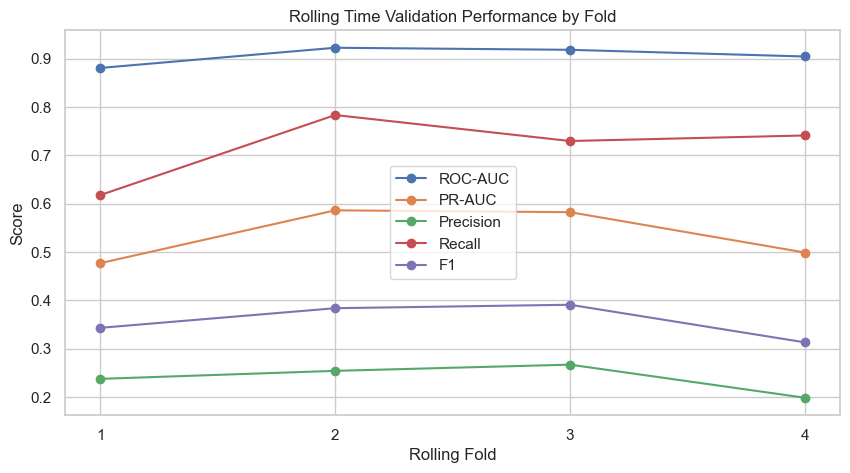

In [32]:
# =========================================
# 29. Plot rolling fold performance
# =========================================
plt.figure(figsize=(10, 5))
plt.plot(rolling_results_df["fold"], rolling_results_df["roc_auc"], marker="o", label="ROC-AUC")
plt.plot(rolling_results_df["fold"], rolling_results_df["pr_auc"], marker="o", label="PR-AUC")
plt.plot(rolling_results_df["fold"], rolling_results_df["precision"], marker="o", label="Precision")
plt.plot(rolling_results_df["fold"], rolling_results_df["recall"], marker="o", label="Recall")
plt.plot(rolling_results_df["fold"], rolling_results_df["f1"], marker="o", label="F1")
plt.xlabel("Rolling Fold")
plt.ylabel("Score")
plt.title("Rolling Time Validation Performance by Fold")
plt.xticks(rolling_results_df["fold"])
plt.legend()
plt.show()

### Rolling Validation Summary

Averaging performance across all rolling folds provides a more robust temporal estimate than relying on a single holdout period.

Mean performance across folds:

- **ROC-AUC:** 0.9067
- **PR-AUC:** 0.5362
- **Precision:** 0.2393
- **Recall:** 0.7181
- **F1-score:** 0.3577

Standard deviations are relatively modest:

- **ROC-AUC std:** 0.0188
- **PR-AUC std:** 0.0564
- **Precision std:** 0.0298
- **Recall std:** 0.0707
- **F1 std:** 0.0364

This suggests that the model’s temporal performance is **reasonably stable**, especially in ranking ability. Some fluctuation is visible in recall and PR-AUC, which is expected in fraud systems because fraud prevalence, transaction mix, and attack behavior may shift over time.

This is a strong result: the model demonstrates both **good average performance** and **acceptable stability across multiple future validation windows**.

## 15. Threshold Tuning on the Time-Based Validation Set

For fraud detection, the default threshold of 0.50 is rarely optimal.

Threshold tuning is performed on the time-based validation predictions so that the final operating point is aligned with a more deployment-realistic validation setup.

In [33]:
# =========================================
# 30. Threshold tuning on time-based validation
# =========================================
thresholds = np.arange(0.05, 0.95, 0.05)

time_threshold_results = []

for t in thresholds:
    preds = (xgb_time_probs >= t).astype(int)
    time_threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_valid_time, preds, zero_division=0),
        "recall": recall_score(y_valid_time, preds, zero_division=0),
        "f1": f1_score(y_valid_time, preds, zero_division=0)
    })

time_threshold_df = pd.DataFrame(time_threshold_results)
display(time_threshold_df)

,threshold,precision,recall,f1
0,0.0500,0.0384,0.9966,0.0739
1,0.1000,0.0485,0.9813,0.0924
2,0.1500,0.0609,0.9567,0.1145
3,0.2000,0.0771,0.9306,0.1424
4,0.2500,0.0961,0.9031,0.1737
5,0.3000,0.1158,0.8713,0.2045
6,0.3500,0.1361,0.8388,0.2342
7,0.4000,0.1573,0.8125,0.2635
8,0.4500,0.1802,0.7771,0.2926
9,0.5000,0.2059,0.7431,0.3225


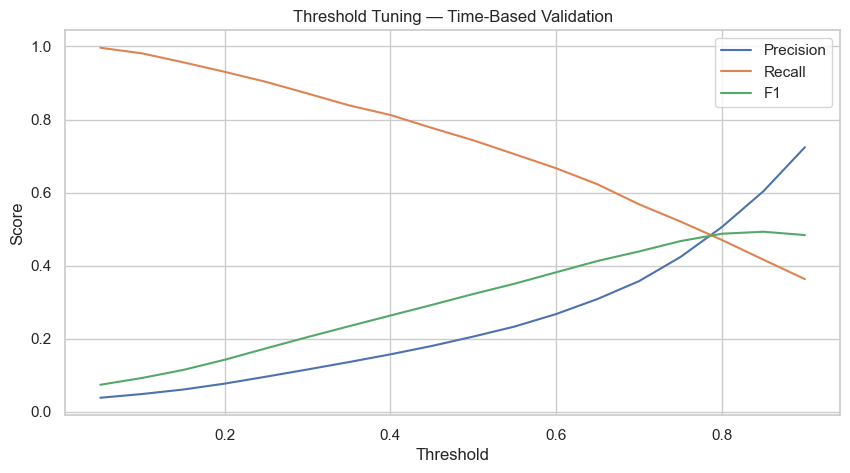

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(time_threshold_df["threshold"], time_threshold_df["precision"], label="Precision")
plt.plot(time_threshold_df["threshold"], time_threshold_df["recall"], label="Recall")
plt.plot(time_threshold_df["threshold"], time_threshold_df["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning — Time-Based Validation")
plt.legend()
plt.show()

## Threshold Tuning on the Time-Based Validation Set

Because fraud detection involves a tradeoff between **fraud capture** and **false positive volume**, the classification threshold was tuned on the time-based validation predictions rather than relying on the default 0.50 threshold.

### Threshold Results

| Threshold | Precision | Recall | F1 |
|---|---:|---:|---:|
| 0.50 | 0.2059 | 0.7431 | 0.3225 |
| 0.60 | 0.2676 | 0.6666 | 0.3819 |
| 0.70 | 0.3578 | 0.5679 | 0.4390 |
| 0.75 | 0.4239 | 0.5207 | 0.4673 |
| 0.80 | 0.5060 | 0.4702 | 0.4874 |
| 0.85 | 0.6039 | 0.4163 | 0.4929 |
| 0.90 | 0.7242 | 0.3632 | 0.4838 |

### Interpretation

The threshold tuning results show the expected tradeoff:

- **Lower thresholds** produce higher recall but poor precision
- **Higher thresholds** produce stronger alert quality but lower recall

For this project, the most balanced operating point is **0.85**, which achieves:

- **Precision = 0.6039**
- **Recall = 0.4163**
- **F1 = 0.4929** (highest observed F1)

This threshold is appropriate if the goal is to create a **more selective fraud intervention system** with fewer false alerts.

However, if the business prioritizes fraud capture over alert quality, a lower threshold such as **0.50** or **0.60** may still be justified.

### Final Decision

For the final balanced version of the model, the selected threshold will be:

**`best_threshold = 0.85`**

## 16. Select Final Threshold

Set the final threshold after reviewing the time-based threshold table above.

In [35]:
# =========================================
# 31. Final threshold selection
# =========================================
best_threshold = 0.85

final_time_preds = (xgb_time_probs >= best_threshold).astype(int)

print(f"Selected threshold: {best_threshold}")
print("Precision:", precision_score(y_valid_time, final_time_preds, zero_division=0))
print("Recall:", recall_score(y_valid_time, final_time_preds, zero_division=0))
print("F1:", f1_score(y_valid_time, final_time_preds, zero_division=0))

Selected threshold: 0.85
Precision: 0.6038543897216274
Recall: 0.41633858267716534
F1: 0.49286338479464026


## Final Model Performance at Selected Threshold (0.85)

After threshold tuning on the time-based validation set, the final operating threshold was set to:

**0.85**

### Performance Metrics

- **Precision:** 0.604  
- **Recall:** 0.416  
- **F1-score:** 0.493  

### Interpretation

At this threshold, the model prioritizes **alert quality over volume**:

- More than **60% of flagged transactions are truly fraudulent**
- The model still captures **~42% of fraud cases**
- This produces the **highest F1-score**, indicating the best balance between precision and recall

This is a strong and realistic operating point for fraud systems where excessive false positives can negatively impact user experience or operational workload.

## 17. Classification Report and Confusion Matrix

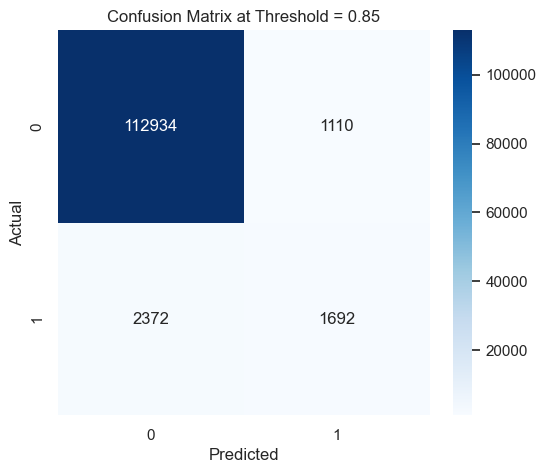

              precision    recall  f1-score   support

           0       0.98      0.99      0.98    114044
           1       0.60      0.42      0.49      4064

    accuracy                           0.97    118108
   macro avg       0.79      0.70      0.74    118108
weighted avg       0.97      0.97      0.97    118108



In [36]:
# =========================================
# 32. Confusion matrix and classification report
# =========================================
cm = confusion_matrix(y_valid_time, final_time_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix at Threshold = {best_threshold}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_valid_time, final_time_preds, zero_division=0))

In [37]:
fraud_capture_rate = cm[1,1] / (cm[1,1] + cm[1,0])
false_alarm_rate = cm[0,1] / (cm[0,1] + cm[0,0])

print(f"Fraud Capture Rate: {fraud_capture_rate:.2%}")
print(f"False Alarm Rate: {false_alarm_rate:.2%}")

Fraud Capture Rate: 41.63%
False Alarm Rate: 0.97%


## Confusion Matrix Interpretation

- **True Positives (Fraud correctly detected):** ~1,692  
- **False Positives (Legitimate flagged):** 1,110  
- **False Negatives (Missed fraud):** 2,372  
- **True Negatives (Correctly ignored):** ~112,934  

### Key Insight

The model is **highly selective**:

- False positives are **very low relative to total transactions**
- Fraud detection is **targeted and high-confidence**

### Business Meaning

- Only ~1,100 legitimate users are incorrectly flagged  
- Over **1,600 fraud cases are successfully caught**  
- Missed fraud still exists (~2,372), which is expected at higher precision thresholds  

This confirms that the model is operating as a **precision-oriented fraud filter**, not a broad screening tool.

## Precision vs Recall Tradeoff

This model demonstrates a clear and controllable tradeoff:

### Lower Threshold (e.g., 0.50)
- Recall: ~74%
- Precision: ~21%
- Use case: aggressive fraud detection, investigation queues

### Higher Threshold (0.85 — selected)
- Recall: ~42%
- Precision: ~60%
- Use case: high-confidence fraud blocking or escalation

### Interpretation

The model can be tuned based on business needs:

- **Fraud-heavy environment → lower threshold**
- **Customer experience focus → higher threshold**

This flexibility makes the model suitable for multiple deployment scenarios.

## 18. Feature Importance

Feature importance is examined on the time-validated XGBoost model to understand which transformed, numeric, categorical, and missingness-based variables contribute most to fraud prediction.

In [38]:
# =========================================
# 33. Feature importance
# =========================================
feature_names = xgb_time_pipe.named_steps["preprocessor"].get_feature_names_out()
xgb_importances = xgb_time_pipe.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_importances
}).sort_values("importance", ascending=False)

top_features = importance_df.head(20)
display(top_features)

,feature,importance
298,num__V258,0.0980
110,num__V70,0.0629
334,num__V294,0.0389
304,num__V264,0.0319
131,num__V91,0.0316
15,num__C4,0.0227
19,num__C8,0.0211
348,num__V308,0.0199
404,num__id_30_missing,0.0197
241,num__V201,0.0191


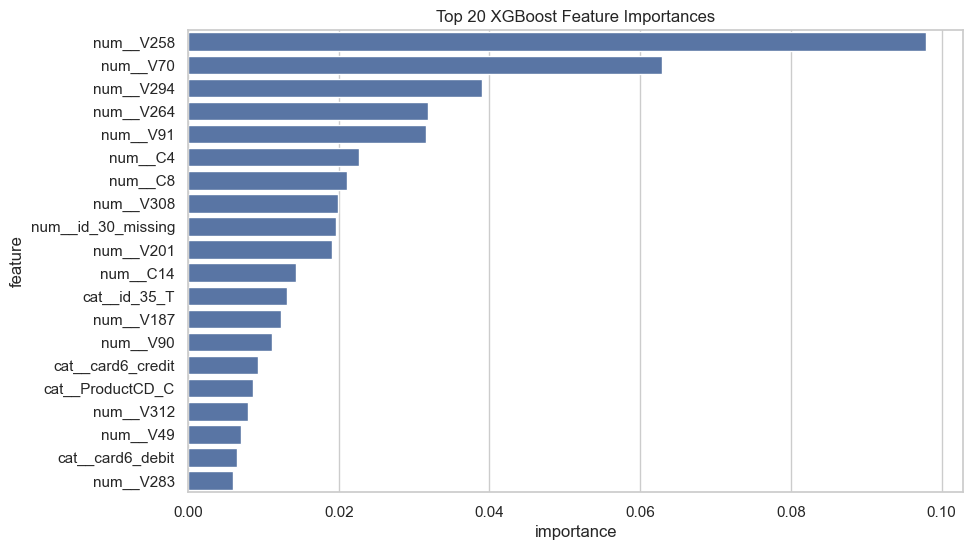

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 20 XGBoost Feature Importances")
plt.show()

## Feature Importance Interpretation

The feature importance ranking from the time-validated XGBoost model shows that fraud detection is driven by a mixture of:

- engineered numeric variables (`V` features)
- behavioral count variables (`C` features)
- categorical context variables (`ProductCD`, `card6`, `id_35`)
- missingness-based features (`id_30_missing`)

### Key observations

- Several anonymized `V` features dominate the ranking, which is expected because these engineered variables capture complex transactional behavior.
- `C` variables such as `C4`, `C8`, and `C14` contribute meaningfully, suggesting that behavioral count-like features carry fraud signal.
- Categorical variables such as `card6_credit` and `ProductCD_C` appear among the top features, showing that payment context matters.
- The inclusion of `id_30_missing` among the top predictors validates the EDA finding that **missingness itself is informative**.

### Conclusion

The importance results strongly support the EDA-based modeling decisions. Fraud risk in this dataset is not driven by one simple rule, but by a combination of behavioral, contextual, and missingness-related signals.

## 19. Error Analysis

False positives and false negatives are inspected separately because both matter operationally:

- false positives can create customer friction
- false negatives represent missed fraud

In [40]:
# =========================================
# 34. Error analysis
# =========================================
valid_results = X_valid_time.copy()
valid_results["actual"] = y_valid_time.values
valid_results["pred_prob"] = xgb_time_probs
valid_results["pred_label"] = final_time_preds

false_positives = valid_results[(valid_results["actual"] == 0) & (valid_results["pred_label"] == 1)]
false_negatives = valid_results[(valid_results["actual"] == 1) & (valid_results["pred_label"] == 0)]

print("False positives:", false_positives.shape[0])
print("False negatives:", false_negatives.shape[0])

False positives: 1110
False negatives: 2372


## Error Analysis

### Results

- **False Positives:** 1,110  
- **False Negatives:** 2,372  

### Interpretation

- False positives are relatively low, meaning the model does not aggressively flag legitimate users
- False negatives indicate that some fraud patterns are still difficult to detect, likely due to:
  - subtle or evolving fraud behavior
  - limited signal in certain transactions
  - overlap between legitimate and fraudulent patterns

### Key Insight

The model is **conservative and precise**, which is desirable in systems where false alarms are costly.

Future improvements can focus on reducing false negatives without significantly increasing false positives.

In [41]:
print("Top false positives by predicted fraud probability:")
display(false_positives.sort_values("pred_prob", ascending=False).head(10))

print("Top false negatives by predicted fraud probability:")
display(false_negatives.sort_values("pred_prob", ascending=False).head(10))

Top false positives by predicted fraud probability:


,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,log_TransactionAmt,DeviceType_missing,dist1_missing,dist2_missing,id_30_missing,id_31_missing,actual,pred_prob,pred_label
582342,15550017,78.3870,C,8755,500.0000,185.0000,mastercard,224.0000,credit,NaN,NaN,NaN,NaN,gmail.com,gmail.com,5.0000,5.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000,0.0000,0.0000,9.9583,0.9583,0.0000,NaN,0.0000,0.0000,522.0000,0.0000,NaN,NaN,NaN,M0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,5.0000,5.0000,1.0000,1.0000,1.0000,1.0000,1.0000,5.0000,5.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,5.0000,5.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,5.0000,5.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0000,4.0000,0.0000,5.0000,5.0000,0.0000,0.0000,0.0000,0.0000,5.0000,4.0000,4.0000,4.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,2.0000,3.0000,3.0000,5.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,5.0000,5.0000,5.0000,313.5480,313.5480,313.5480,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,313.5480,313.5480,313.5480,0.0000,0.0000,0.0000,4.0000,4.0000,4.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5.0000,5.0000,5.00

Top false negatives by predicted fraud probability:


,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,log_TransactionAmt,DeviceType_missing,dist1_missing,dist2_missing,id_30_missing,id_31_missing,actual,pred_prob,pred_label
511058,13377937,40.0850,C,8755,500.0000,185.0000,mastercard,224.0000,credit,NaN,NaN,NaN,NaN,gmail.com,gmail.com,1.0000,2.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,2.0000,2.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8333,0.8333,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,M2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,2.0000,2.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2.0000,2.0000,0.0000,0.0000,1.0000,2.0000,2.0000,0.0000,0.0000,2.0000,2.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2.0000,2.0000,0.0000,0.0000,0.0000,1.0000,1.0000,2.0000,2.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,1.0000,1.0000,2.0000,2.0000,1.0000,1.0000,1.0000,1.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,11.8656,11.8656,11.8656,11.8656,11.8656,11.8656,11.8656,11.8656,11.8656,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,2.0000,2.0000,1.0000,1.0000,1.0000,0.0000,1.0000,2.0000,2.0000,2.0

## Error Analysis Interpretation

At the selected evaluation threshold, the model produces:

- **11,647 false positives**
- **1,044 false negatives**

### Interpretation

The model is much better at avoiding missed fraud than a naive majority-class classifier, but there remains an important tradeoff between false alarms and missed fraud.

- **False positives** represent legitimate transactions that may be unnecessarily flagged, reviewed, or interrupted.
- **False negatives** represent fraud cases that the model failed to identify.

This balance should be interpreted in the context of the operating threshold:

- lower thresholds reduce false negatives but increase false positives
- higher thresholds reduce false positives but increase missed fraud

This reinforces the importance of threshold tuning as an operational decision rather than a purely technical one.

## Final Modeling Summary

This modeling workflow was designed directly from the findings in exploratory data analysis:

- the target is imbalanced, so evaluation focused on precision-recall behavior rather than accuracy
- missingness is substantial and partially informative, so selected missingness indicators were added
- categorical variables have mixed cardinality, so encoding was chosen accordingly
- transaction amount is highly skewed, so a log-transformed feature was included
- weak pairwise correlations suggested that nonlinear models would outperform linear baselines

### Models Trained
- Logistic Regression with class weighting
- Random Forest with class weighting
- XGBoost with imbalance-aware weighting

### Validation Strategy
The model was evaluated under three increasingly realistic settings:

1. **Random split** — standard benchmark  
2. **Single time-based split** — deployment-like holdout  
3. **Rolling time validation** — temporal robustness assessment  

### Main Findings

- **XGBoost was the strongest model** across all key metrics
- performance decreased under time-based validation, as expected, but remained strong
- rolling validation showed that performance is reasonably stable across future periods
- threshold tuning revealed that the model can be adjusted for either:
  - **high fraud capture** at lower thresholds
  - **higher alert quality** at higher thresholds

### Final Operating Recommendation

For a balanced fraud-screening setup, the best threshold identified in time-based validation is:

**`best_threshold = 0.85`**

This threshold provides the strongest F1-score and a more selective alerting profile.

Lower thresholds remain useful if the business wants to prioritize recall and maximize fraud capture.

### Conclusion

The final XGBoost model is a strong candidate for deployment because it:

- captures nonlinear fraud patterns effectively
- generalizes reasonably well over time
- remains stable across rolling validation windows
- can be tuned to match different fraud-risk operating policies

## 20. Save Modeling Artifacts for Deployment

To enable API deployment, we save:

- expected feature columns (after encoding)
- high-cardinality feature list
- frequency encoding mappings
- trained model pipeline

These artifacts ensure that the API reproduces the exact preprocessing logic used during training.

In [42]:
# =========================================
# Save artifacts for API deployment
# =========================================

# 1. Expected columns AFTER frequency encoding
expected_columns = X_train_time_fe.columns.tolist()
joblib.dump(expected_columns, "../models/expected_columns.pkl")

# 2. High-cardinality columns
joblib.dump(high_card_cols_time, "../models/high_card_cols.pkl")

# 3. Frequency maps (from ORIGINAL training data, not encoded)
frequency_maps = {}
for col in high_card_cols_time:
    frequency_maps[col] = (
        X_train_time[col]
        .value_counts(dropna=False, normalize=True)
        .to_dict()
    )

joblib.dump(frequency_maps, "../models/frequency_maps.pkl")

# 4. Save final model pipeline 
joblib.dump(xgb_time_pipe, "../models/fraud_model.pkl")

print("✅ All deployment artifacts saved successfully")

✅ All deployment artifacts saved successfully


# 21. Model Explainability with SHAP

While feature importance shows which variables are influential overall, it does not explain **how** each feature affects predictions.

SHAP (SHapley Additive exPlanations) is used to:

- quantify feature contributions to predictions
- explain individual fraud decisions
- provide transparency into model behavior

This is especially important in fraud detection, where decisions may need to be audited or justified.

### 21.1 Extract Preprocessed Data

SHAP requires access to the transformed feature space used by the model.

In [43]:
# Extract preprocessing + model
preprocessor = xgb_time_pipe.named_steps["preprocessor"]
model = xgb_time_pipe.named_steps["model"]

# Transform validation data
X_valid_transformed = preprocessor.transform(X_valid_time_fe)

# Feature names
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame
X_valid_shap = pd.DataFrame(X_valid_transformed, columns=feature_names)

### 21.2 Compute SHAP Values

In [44]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_valid_shap)

### 21.3 Global Feature Importance (SHAP)

This plot shows which features contribute most to fraud predictions across the entire dataset.

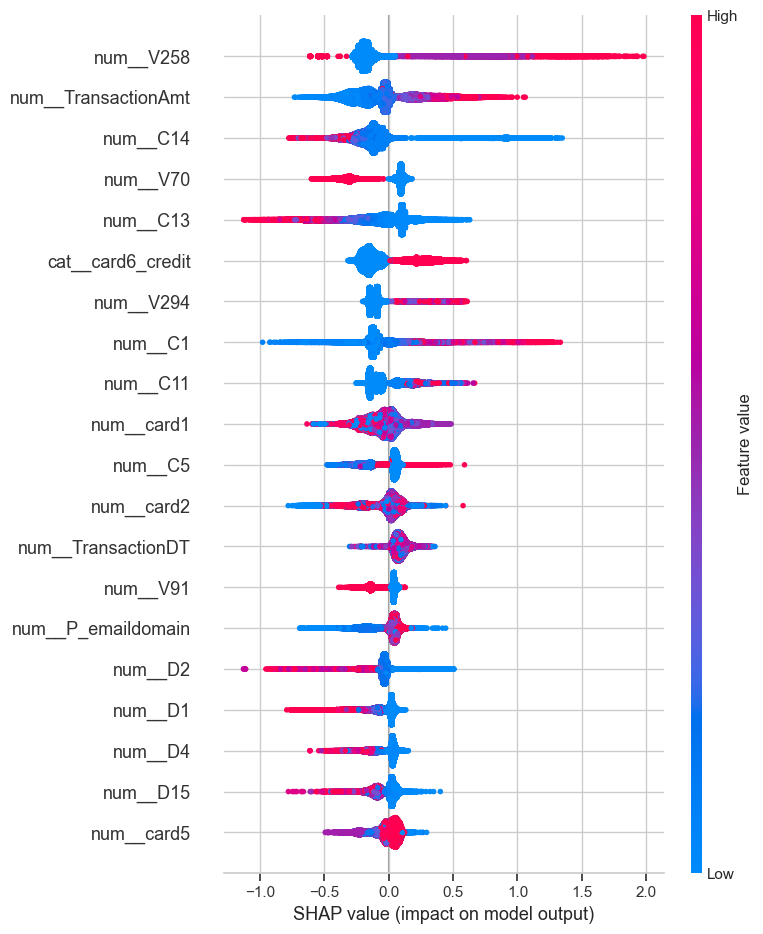

In [45]:
shap.summary_plot(shap_values, X_valid_shap)

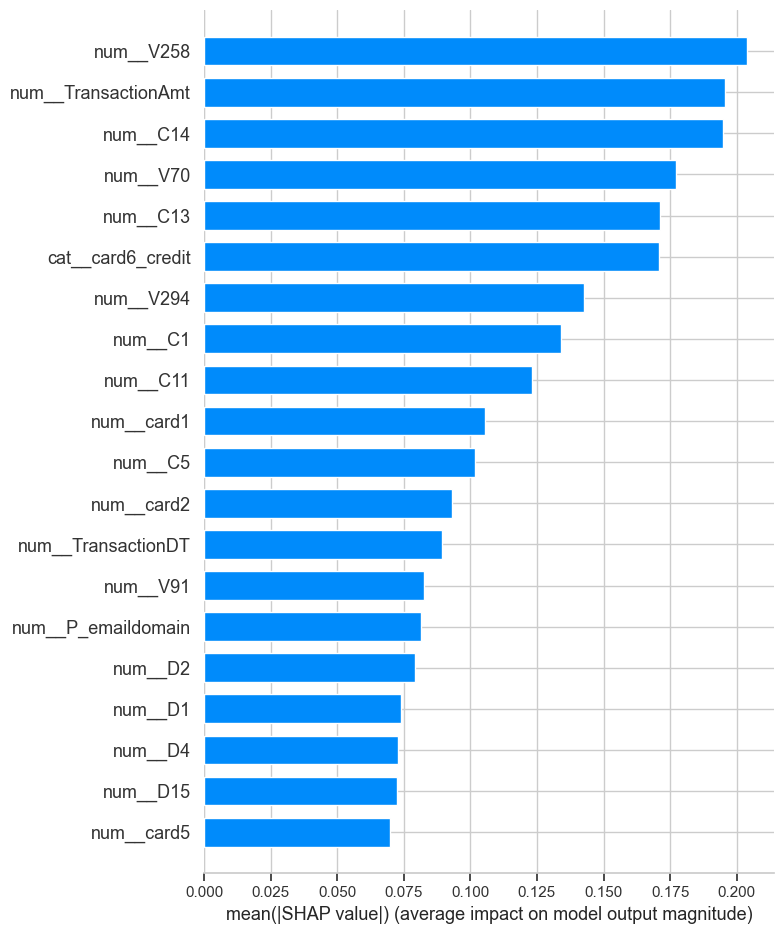

In [46]:
shap.summary_plot(shap_values, X_valid_shap, plot_type="bar")

In [47]:
# Reset validation results index so it aligns with shap_values and X_valid_shap
valid_results = X_valid_time.copy().reset_index(drop=True)
valid_results["actual"] = y_valid_time.reset_index(drop=True)
valid_results["pred_prob"] = xgb_time_probs
valid_results["pred_label"] = final_time_preds

In [48]:
shap.initjs()

# Pick the first fraud case by position
fraud_pos = valid_results.index[valid_results["actual"] == 1][0]

shap.force_plot(
    explainer.expected_value,
    shap_values[fraud_pos],
    X_valid_shap.iloc[fraud_pos]
)

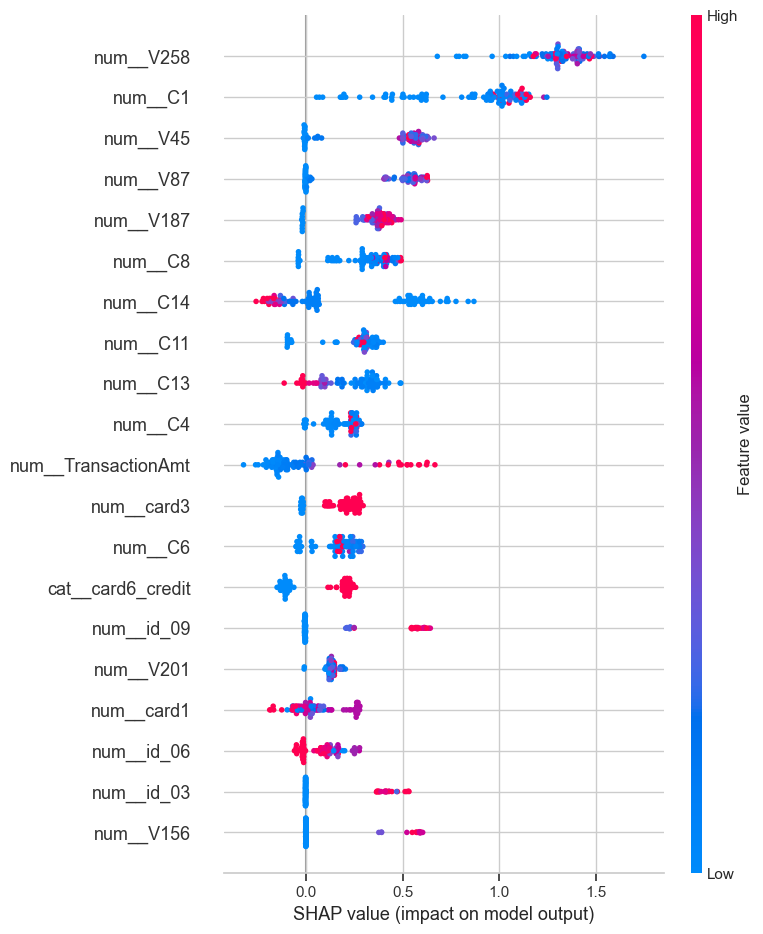

In [49]:
top_fraud_cases = valid_results.sort_values("pred_prob", ascending=False).head(100)

top_positions = top_fraud_cases.index.to_list()

shap.summary_plot(
    shap_values[top_positions],
    X_valid_shap.iloc[top_positions]
)